# GBMEncoder 缺失值处理示例

展示 GBMEncoder 如何处理包含缺失值的数据。

## 缺失值支持特性

XGBoost、LightGBM 和 CatBoost 都原生支持缺失值处理：
- **XGBoost**: 自动学习缺失值的最优分裂方向（稀疏感知）
- **LightGBM**: 自动处理缺失值，无需填充
- **CatBoost**: 将缺失值作为特殊类别处理


In [1]:
# 导入必要的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.pipeline import Pipeline

# 导入 hscredit 的 GBMEncoder
import sys
sys.path.insert(0, '/Users/xiaoxi/CodeBuddy/hscredit/hscredit')
from hscredit.core.encoders import GBMEncoder

print("✓ 所有库导入成功")

✓ 所有库导入成功


## 1. 生成带缺失值的示例数据

In [2]:
def generate_data_with_missing(
    n_samples=10000, 
    n_features=20, 
    missing_ratio=0.1,  # 10%的缺失率
    random_state=42
):
    """生成包含缺失值的示例数据."""
    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=15,
        n_redundant=5,
        n_classes=2,
        random_state=random_state
    )
    
    X_df = pd.DataFrame(X, columns=[f'feat_{i}' for i in range(n_features)])
    
    # 添加类别特征
    X_df['cat_1'] = np.random.choice(['A', 'B', 'C', 'D'], size=n_samples)
    X_df['cat_2'] = np.random.choice(['X', 'Y', 'Z'], size=n_samples)
    
    # 随机引入缺失值
    np.random.seed(random_state)
    
    # 数值特征缺失
    for col in X_df.select_dtypes(include=[np.number]).columns:
        missing_mask = np.random.random(n_samples) < missing_ratio
        X_df.loc[missing_mask, col] = np.nan
    
    # 类别特征缺失
    for col in ['cat_1', 'cat_2']:
        missing_mask = np.random.random(n_samples) < missing_ratio
        X_df.loc[missing_mask, col] = np.nan
    
    return X_df, pd.Series(y, name='target')

# 生成带缺失值的数据
X, y = generate_data_with_missing(n_samples=10000, missing_ratio=0.15)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"训练集大小: {len(X_train)}")
print(f"测试集大小: {len(X_test)}")

训练集大小: 8000
测试集大小: 2000


In [3]:
# 查看缺失值统计
print("\n=== 训练集缺失值统计 ===")
missing_stats = X_train.isnull().sum()
missing_stats = missing_stats[missing_stats > 0].sort_values(ascending=False)

if len(missing_stats) > 0:
    missing_df = pd.DataFrame({
        'feature': missing_stats.index,
        'missing_count': missing_stats.values,
        'missing_ratio': (missing_stats.values / len(X_train) * 100).round(2)
    })
    print(missing_df.to_string(index=False))
else:
    print("没有缺失值")


=== 训练集缺失值统计 ===
feature  missing_count  missing_ratio
  cat_1           1260          15.75
 feat_0           1259          15.74
feat_12           1249          15.61
 feat_9           1242          15.52
 feat_8           1233          15.41
 feat_4           1216          15.20
 feat_3           1212          15.15
feat_19           1212          15.15
feat_15           1212          15.15
feat_11           1209          15.11
feat_17           1208          15.10
feat_10           1194          14.92
 feat_2           1188          14.85
 feat_6           1186          14.82
 feat_1           1184          14.80
feat_16           1184          14.80
  cat_2           1176          14.70
feat_13           1170          14.62
 feat_5           1165          14.56
feat_14           1151          14.39
 feat_7           1150          14.37
feat_18           1128          14.10


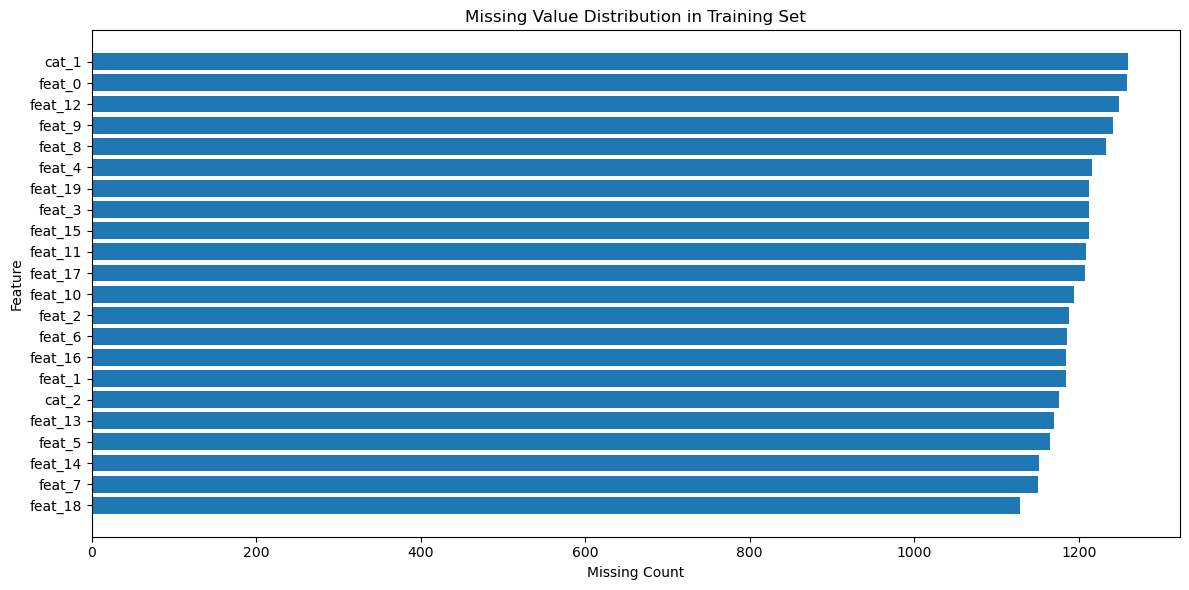

In [4]:
# 可视化缺失值分布
plt.figure(figsize=(12, 6))
missing_counts = X_train.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=True)

if len(missing_counts) > 0:
    plt.barh(missing_counts.index, missing_counts.values)
    plt.xlabel('Missing Count')
    plt.ylabel('Feature')
    plt.title('Missing Value Distribution in Training Set')
    plt.tight_layout()
    plt.show()
else:
    print("没有缺失值需要可视化")

## 2. XGBoost 处理缺失值

In [5]:
# 创建GBM编码器
print("=== XGBoost + 缺失值 ===")
encoder_xgb = GBMEncoder(
    model_type='xgboost',
    n_estimators=50,
    max_depth=4,
    output_type='embedding',
    drop_origin=True,
    random_state=42
)

# 拟合（会自动处理缺失值）
X_train_xgb = encoder_xgb.fit_transform(X_train, y_train)
X_test_xgb = encoder_xgb.transform(X_test)

print(f"\nXGBoost编码后维度: {X_train_xgb.shape[1]}")

=== XGBoost + 缺失值 ===
警告: 22 个特征存在缺失值，GBM将自动处理

XGBoost编码后维度: 50


In [6]:
# 查看缺失值统计
missing_stats_df = encoder_xgb.get_missing_stats()
print("\n=== XGBoost 缺失值统计 ===")
if len(missing_stats_df) > 0:
    print(missing_stats_df.to_string(index=False))
else:
    print("没有缺失值")


=== XGBoost 缺失值统计 ===
feature  missing_count  missing_ratio
  cat_1           1260       0.157500
 feat_0           1259       0.157375
feat_12           1249       0.156125
 feat_9           1242       0.155250
 feat_8           1233       0.154125
 feat_4           1216       0.152000
 feat_3           1212       0.151500
feat_19           1212       0.151500
feat_15           1212       0.151500
feat_11           1209       0.151125
feat_17           1208       0.151000
feat_10           1194       0.149250
 feat_2           1188       0.148500
 feat_6           1186       0.148250
 feat_1           1184       0.148000
feat_16           1184       0.148000
  cat_2           1176       0.147000
feat_13           1170       0.146250
 feat_5           1165       0.145625
feat_14           1151       0.143875
 feat_7           1150       0.143750
feat_18           1128       0.141000


In [7]:
# XGBoost + LR
lr_xgb = LogisticRegression(max_iter=1000)
lr_xgb.fit(X_train_xgb, y_train)

y_pred_xgb = lr_xgb.predict_proba(X_test_xgb)[:, 1]
auc_xgb = roc_auc_score(y_test, y_pred_xgb)
acc_xgb = accuracy_score(y_test, (y_pred_xgb > 0.5).astype(int))

print(f"\nXGBoost+LR (带缺失值) AUC: {auc_xgb:.4f}")
print(f"XGBoost+LR (带缺失值) Accuracy: {acc_xgb:.4f}")


XGBoost+LR (带缺失值) AUC: 0.9420
XGBoost+LR (带缺失值) Accuracy: 0.8720


## 3. LightGBM 处理缺失值

In [8]:
print("=== LightGBM + 缺失值 ===")

try:
    encoder_lgb = GBMEncoder(
        model_type='lightgbm',
        n_estimators=50,
        max_depth=4,
        output_type='probability',
        drop_origin=True,
        random_state=42
    )
    
    X_train_lgb = encoder_lgb.fit_transform(X_train, y_train)
    X_test_lgb = encoder_lgb.transform(X_test)
    
    lr_lgb = LogisticRegression(max_iter=1000)
    lr_lgb.fit(X_train_lgb, y_train)
    
    y_pred_lgb = lr_lgb.predict_proba(X_test_lgb)[:, 1]
    auc_lgb = roc_auc_score(y_test, y_pred_lgb)
    acc_lgb = accuracy_score(y_test, (y_pred_lgb > 0.5).astype(int))
    
    print(f"\nLightGBM+LR (带缺失值) AUC: {auc_lgb:.4f}")
    print(f"LightGBM+LR (带缺失值) Accuracy: {acc_lgb:.4f}")
    
except ImportError:
    print("未安装 LightGBM，跳过")

=== LightGBM + 缺失值 ===
警告: 22 个特征存在缺失值，GBM将自动处理

LightGBM+LR (带缺失值) AUC: 0.9476
LightGBM+LR (带缺失值) Accuracy: 0.8815


## 4. CatBoost 处理缺失值（含类别特征缺失）

In [9]:
print("=== CatBoost + 缺失值 ===")

try:
    encoder_cb = GBMEncoder(
        model_type='catboost',
        n_estimators=50,
        max_depth=4,
        output_type='probability',
        drop_origin=True,
        random_state=42
    )
    
    X_train_cb = encoder_cb.fit_transform(X_train, y_train)
    X_test_cb = encoder_cb.transform(X_test)
    
    lr_cb = LogisticRegression(max_iter=1000)
    lr_cb.fit(X_train_cb, y_train)
    
    y_pred_cb = lr_cb.predict_proba(X_test_cb)[:, 1]
    auc_cb = roc_auc_score(y_test, y_pred_cb)
    acc_cb = accuracy_score(y_test, (y_pred_cb > 0.5).astype(int))
    
    print(f"\nCatBoost+LR (带缺失值) AUC: {auc_cb:.4f}")
    print(f"CatBoost+LR (带缺失值) Accuracy: {acc_cb:.4f}")
    
except ImportError:
    print("未安装 CatBoost，跳过")

=== CatBoost + 缺失值 ===
警告: 22 个特征存在缺失值，GBM将自动处理

CatBoost+LR (带缺失值) AUC: 0.9280
CatBoost+LR (带缺失值) Accuracy: 0.8475


## 5. 对比：有缺失值 vs 无缺失值

In [10]:
# 生成无缺失值的数据
X_clean, y_clean = generate_data_with_missing(n_samples=10000, missing_ratio=0.0)
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

print("=== 对比：无缺失值数据 ===")

encoder_clean = GBMEncoder(
    model_type='xgboost',
    n_estimators=50,
    max_depth=4,
    output_type='probability',
    drop_origin=True,
    random_state=42
)

X_train_clean_enc = encoder_clean.fit_transform(X_train_clean, y_train_clean)
X_test_clean_enc = encoder_clean.transform(X_test_clean)

lr_clean = LogisticRegression(max_iter=1000)
lr_clean.fit(X_train_clean_enc, y=y_train_clean)

y_pred_clean = lr_clean.predict_proba(X_test_clean_enc)[:, 1]
auc_clean = roc_auc_score(y_test_clean, y_pred_clean)

print(f"无缺失值 AUC: {auc_clean:.4f}")
print(f"有缺失值 AUC: {auc_xgb:.4f}")
print(f"性能差异: {abs(auc_clean - auc_xgb):.4f}")

=== 对比：无缺失值数据 ===
无缺失值 AUC: 0.9705
有缺失值 AUC: 0.9420
性能差异: 0.0285


## 6. 不同缺失率对比实验

In [11]:
# 测试不同缺失率
missing_ratios = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3]
results = []

for ratio in missing_ratios:
    X_temp, y_temp = generate_data_with_missing(n_samples=5000, missing_ratio=ratio)
    X_tr, X_te, y_tr, y_te = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)
    
    encoder = GBMEncoder(
        model_type='xgboost',
        n_estimators=30,
        max_depth=3,
        output_type='probability',
        drop_origin=True,
        random_state=42
    )
    
    X_tr_enc = encoder.fit_transform(X_tr, y_tr)
    X_te_enc = encoder.transform(X_te)
    
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_tr_enc, y_tr)
    
    y_pr = lr.predict_proba(X_te_enc)[:, 1]
    auc = roc_auc_score(y_te, y_pr)
    
    results.append({'missing_ratio': ratio, 'auc': auc})
    print(f"缺失率 {ratio*100:>5.1f}%: AUC = {auc:.4f}")

results_df = pd.DataFrame(results)

缺失率   0.0%: AUC = 0.9344
警告: 22 个特征存在缺失值，GBM将自动处理
缺失率   5.0%: AUC = 0.9283
警告: 22 个特征存在缺失值，GBM将自动处理
缺失率  10.0%: AUC = 0.9164
警告: 22 个特征存在缺失值，GBM将自动处理
缺失率  15.0%: AUC = 0.9006
警告: 22 个特征存在缺失值，GBM将自动处理
缺失率  20.0%: AUC = 0.8983
警告: 22 个特征存在缺失值，GBM将自动处理
缺失率  30.0%: AUC = 0.8641


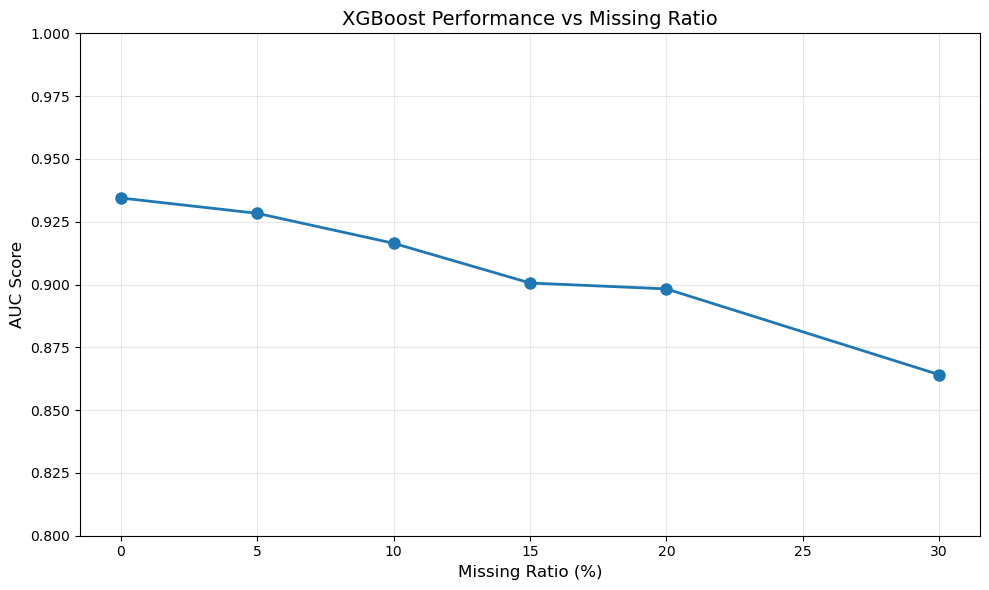

In [12]:
# 可视化不同缺失率的性能
plt.figure(figsize=(10, 6))
plt.plot(results_df['missing_ratio'] * 100, results_df['auc'], marker='o', linewidth=2, markersize=8)
plt.xlabel('Missing Ratio (%)', fontsize=12)
plt.ylabel('AUC Score', fontsize=12)
plt.title('XGBoost Performance vs Missing Ratio', fontsize=14)
plt.grid(True, alpha=0.3)
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.show()

## 7. Pipeline 中使用

In [13]:
# 带缺失值的Pipeline
print("=== Pipeline + 缺失值 ===")

pipeline = Pipeline([
    ('gbm', GBMEncoder(
        model_type='xgboost',
        n_estimators=30,
        max_depth=3,
        output_type='probability',
        drop_origin=True,
        random_state=42
    )),
    ('lr', LogisticRegression(max_iter=1000))
])

# 直接使用带缺失值的数据
pipeline.fit(X_train, y_train)
y_pred_pipe = pipeline.predict_proba(X_test)[:, 1]
auc_pipe = roc_auc_score(y_test, y_pred_pipe)

print(f"\nPipeline (带缺失值) AUC: {auc_pipe:.4f}")

=== Pipeline + 缺失值 ===
警告: 22 个特征存在缺失值，GBM将自动处理

Pipeline (带缺失值) AUC: 0.9196


## 8. 特征重要性（含缺失值处理）

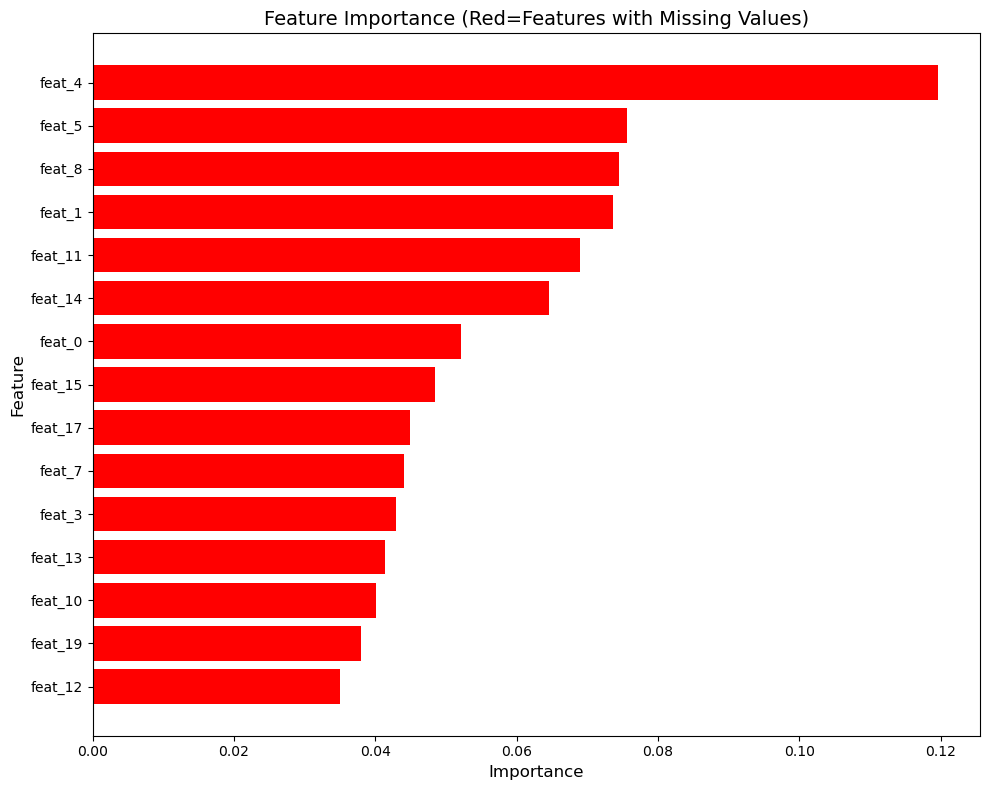


红色条表示包含缺失值的特征


In [14]:
# 查看特征重要性
importance = encoder_xgb.get_feature_importance()

plt.figure(figsize=(10, 8))
top_15 = importance.head(15)
colors = ['red' if feat in missing_stats_df['feature'].values else 'steelblue' 
          for feat in top_15['feature']]

plt.barh(top_15['feature'], top_15['importance'], color=colors)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance (Red=Features with Missing Values)', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n红色条表示包含缺失值的特征")

## 总结

GBMEncoder 完美支持缺失值输入：

1. **数值特征缺失**: GBM模型自动学习最优分裂方向
2. **类别特征缺失**: 
   - XGBoost/LightGBM: 编码时保留为np.nan
   - CatBoost: 原生支持类别特征缺失
3. **无需预处理**: 不需要填充或删除缺失值
4. **性能影响**: 适度缺失率(10-20%)对性能影响很小

**建议**: 
- 缺失率 < 30%: 直接使用GBMEncoder
- 缺失率 > 30%: 考虑特征工程或补充数据
- 类别特征缺失: 推荐使用CatBoost